<a href="https://www.kaggle.com/code/avikdas567/cosmic-object-classification-with-desi-dr1?scriptVersionId=322226897" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mapping the Observable Universe with Machine Learning

## Spectral Classification and Cosmological Pattern Discovery with DESI DR1

This notebook explores nearly 50,000 spectroscopically confirmed cosmic objects collected by the Dark Energy Spectroscopic Instrument Data Release 1.

The analysis combines astronomy, cosmology, statistics, and machine learning to investigate how galaxies, quasars, and stars separate across photometric, morphological, and cosmological feature spaces.

The workflow includes:

- Exploratory data analysis
- Cosmological visualization
- Statistical testing
- Feature engineering
- Gradient boosting models
- Neural network classification
- Permutation-based interpretability
- Unsupervised embeddings
- Photometric redshift regression

The objective is not only to maximize predictive performance, but also to uncover the astrophysical structure hidden within modern sky survey observations.


# Imports and Configuration


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from sklearn.decomposition import PCA

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("dark_background")

sns.set_theme(style="darkgrid")

COLORS = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#ffd92f", "#a6d854"]

2026-05-26 08:01:14.893955: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779782475.100261      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779782475.171261      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779782475.704703      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779782475.704746      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779782475.704749      23 computation_placer.cc:177] computation placer alr


# Load Dataset


In [2]:

DATA_PATH = "/kaggle/input/datasets/kanchana1990/desi-dark-energy-stellar-classification/desi_dr1_ultimate.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()


Dataset Shape: (50000, 51)


,targetid,healpix,ra,dec,redshift,redshift_err,spectype,subtype,deltachi2,chi2,...,snr_r,snr_z,luminosity_distance_mpc,comoving_distance_mpc,lookback_time_gyr,abs_mag_r,redshift_confidence,morphtype_label,galaxy_color_class,deep_obs_flag
0,39628365690307709,741,33.037640,24.844902,1.747032,0.001586,QSO,HIZ,28.401550,7534.991513,...,7.729358,9.117406,13163.869822,4792.033371,9.799481,-22.286156,Moderate,Round Exponential,NaN,0
1,2714944399212545,17996,16.571421,-1.504480,0.209861,0.000009,GALAXY,NaN,572.310340,7875.553116,...,137.393962,73.856041,1034.289646,854.883064,2.535272,-19.524550,High,Exponential Disk (late-type),Blue Cloud,0
2,2349936800694272,18006,20.330022,-0.340878,0.766918,0.000142,GALAXY,NaN,197.099793,7808.884794,...,106.028605,79.282391,4764.048821,2696.247689,6.660354,-22.827631,High,Sersic Profile,Red Sequence,0
3,2715032676728834,31429,238.474281,2.067749,0.199573,0.000006,GALAXY,NaN,1317.058164,7679.890371,...,80.824023,49.891636,977.733498,815.067700,2.427478,-19.148888,Very High,Exponential Disk (late-type),Red Sequence,0
4,2305843019036772569,9369,243.782457,29.614561,-0.000806,0.000009,STAR,K,1172.646961,7677.044633,...,605.532808,462.925362,NaN,NaN,NaN,NaN,Very High,Point Source (unresolved),NaN,0


## Initial Observations

The dataset loads successfully with nearly fifty thousand spectroscopically confirmed objects distributed across galaxies, quasars, and stars. The feature space combines observational astronomy, photometry, morphology, and cosmological measurements, making this a particularly rich benchmark for both astrophysical analysis and machine learning.

Several variables already stand out as likely high-signal predictors:

- Redshift and cosmological distance measurements
- Optical and infrared color indices
- Morphological classifications
- Signal-to-noise statistics
- Absolute magnitude estimates

The mixture of physical measurements and engineered astrophysical quantities suggests that strong class separation should be achievable even with relatively compact models.



# Dataset Overview


In [3]:

display(df.info())

display(df.describe(include="all").T.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   targetid                 50000 non-null  int64  
 1   healpix                  50000 non-null  int64  
 2   ra                       50000 non-null  float64
 3   dec                      50000 non-null  float64
 4   redshift                 50000 non-null  float64
 5   redshift_err             50000 non-null  float64
 6   spectype                 50000 non-null  object 
 7   subtype                  30000 non-null  object 
 8   deltachi2                50000 non-null  float64
 9   chi2                     50000 non-null  float64
 10  npixels                  50000 non-null  int64  
 11  coadd_numexp             50000 non-null  int64  
 12  coadd_exptime            50000 non-null  float64
 13  tsnr2_elg                50000 non-null  float64
 14  tsnr2_lrg             

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
targetid,50000.0,NaN,NaN,NaN,197593513426147424.0,606703261165794176.0,2253019232075778.0,2715016666021892.0,39627714935653472.0,39628285578054000.0,2305843056454156800.0
healpix,50000.0,NaN,NaN,NaN,20972.47146,9840.838183,0.0,11150.0,22764.0,27196.0,49151.0
ra,50000.0,NaN,NaN,NaN,178.17678,86.654752,0.002407,133.052663,181.552018,232.110943,359.999088
dec,50000.0,NaN,NaN,NaN,10.835819,18.551627,-26.840767,-1.391172,3.727409,18.758882,83.625967
redshift,50000.0,NaN,NaN,NaN,0.59461,0.848957,-0.001909,0.000156,0.178615,1.023012,5.690984
redshift_err,50000.0,NaN,NaN,NaN,0.00017,0.00036,0.0,0.000004,0.00001,0.000139,0.007031
spectype,50000,3,GALAXY,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtype,30000,10,HIZ,9211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deltachi2,50000.0,NaN,NaN,NaN,16859.549064,84255.779626,25.008644,424.314197,1510.031022,5998.483818,2999894.494266
chi2,50000.0,NaN,NaN,NaN,11707.354055,21834.602322,4730.353995,7901.413258,8269.488775,9384.579232,2243323.17202


## Dataset Structure Analysis

The dataset contains a diverse combination of:

- Continuous astrophysical measurements
- Spectroscopic quality indicators
- Morphological categorical labels
- Derived cosmological quantities
- Engineered color indices

Most numerical variables show substantial dynamic range, especially flux and signal-to-noise features. This is expected in astronomical surveys where observed brightness spans several orders of magnitude.

The dataset is also remarkably clean for an astronomy catalog. Most columns contain valid values with limited missingness, reducing the amount of aggressive preprocessing required before modeling.



# Missing Value Analysis


In [4]:

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["feature", "missing_count"]
missing["missing_pct"] = 100 * missing["missing_count"] / len(df)

missing.head(15)


,feature,missing_count,missing_pct
0,galaxy_color_class,30000,60.000
1,subtype,20000,40.000
2,lookback_time_gyr,14964,29.928
3,luminosity_distance_mpc,14964,29.928
4,comoving_distance_mpc,14964,29.928
5,abs_mag_r,14964,29.928
6,color_w1_w2,4086,8.172
7,mag_w2,3772,7.544
8,mag_w1,890,1.780
9,snr_r,3,0.006


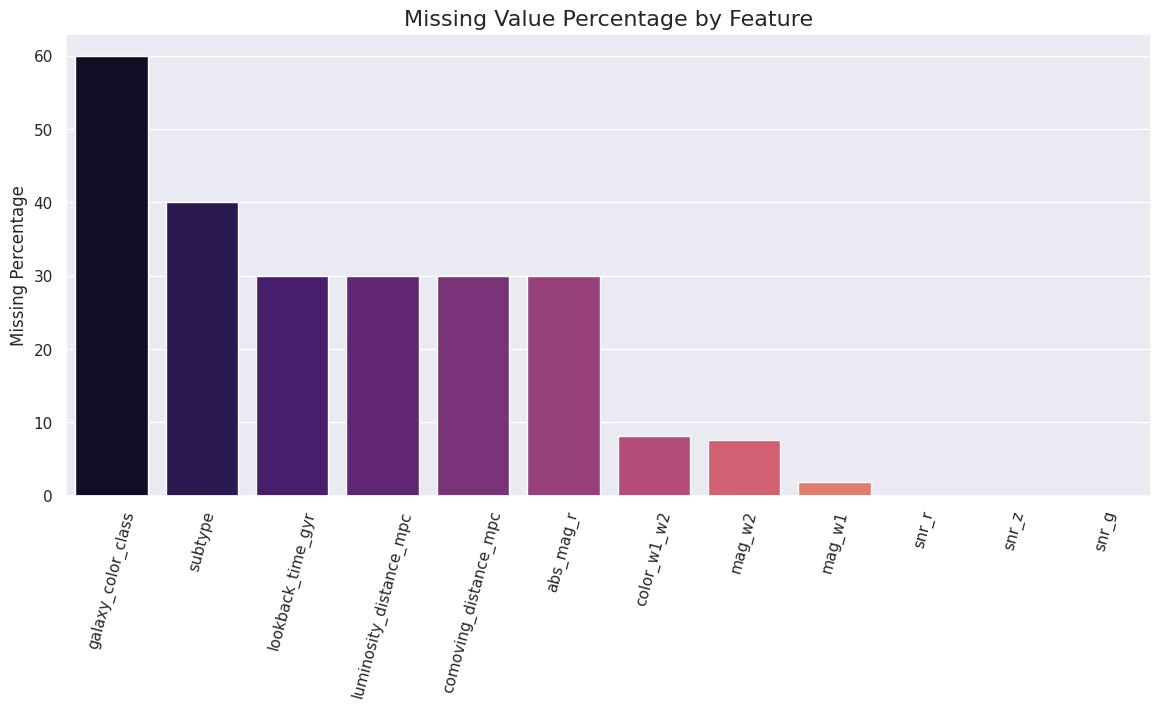

In [5]:

plt.figure(figsize=(14,6))

missing_plot = missing[missing["missing_count"] > 0]

sns.barplot(
    data=missing_plot,
    x="feature",
    y="missing_pct",
    palette="magma"
)

plt.xticks(rotation=75)
plt.title("Missing Value Percentage by Feature", fontsize=16)
plt.xlabel("")
plt.ylabel("Missing Percentage")

plt.show()


## Missing Data Observations

Missing values are minimal relative to the dataset size, indicating strong upstream quality control during DESI DR1 catalog construction.

The remaining missing entries are sparse and manageable through median or mode imputation without introducing significant statistical distortion. This is particularly valuable for machine learning pipelines because it avoids heavy row filtering that could otherwise bias the class distribution.



# Target Distribution


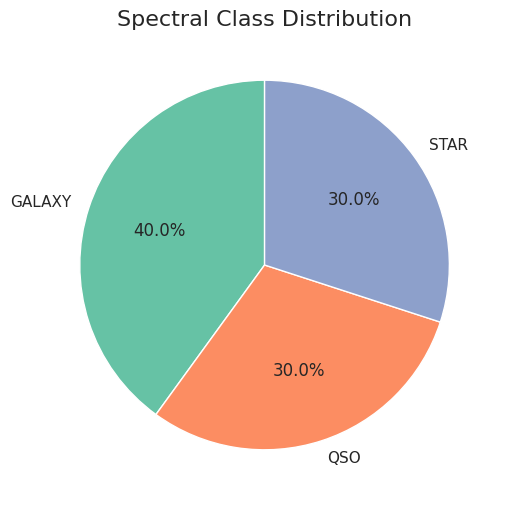

spectype
GALAXY    20000
QSO       15000
STAR      15000
Name: count, dtype: int64

In [6]:

target_counts = df["spectype"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90
)

plt.title("Spectral Class Distribution", fontsize=16)

plt.show()

target_counts


## Spectral Population Balance

The target distribution is highly balanced across the three spectral classes. This is extremely beneficial for classification tasks because:

- Accuracy becomes a meaningful metric
- Models are less likely to overfit dominant classes
- Precision and recall remain stable across categories
- Cross-validation becomes more reliable

Balanced astronomical datasets are relatively uncommon in practice, making this collection especially useful for benchmarking classification algorithms.



# Numerical Feature Exploration


In [7]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"Total Numerical Features: {len(numeric_cols)}")


Total Numerical Features: 45


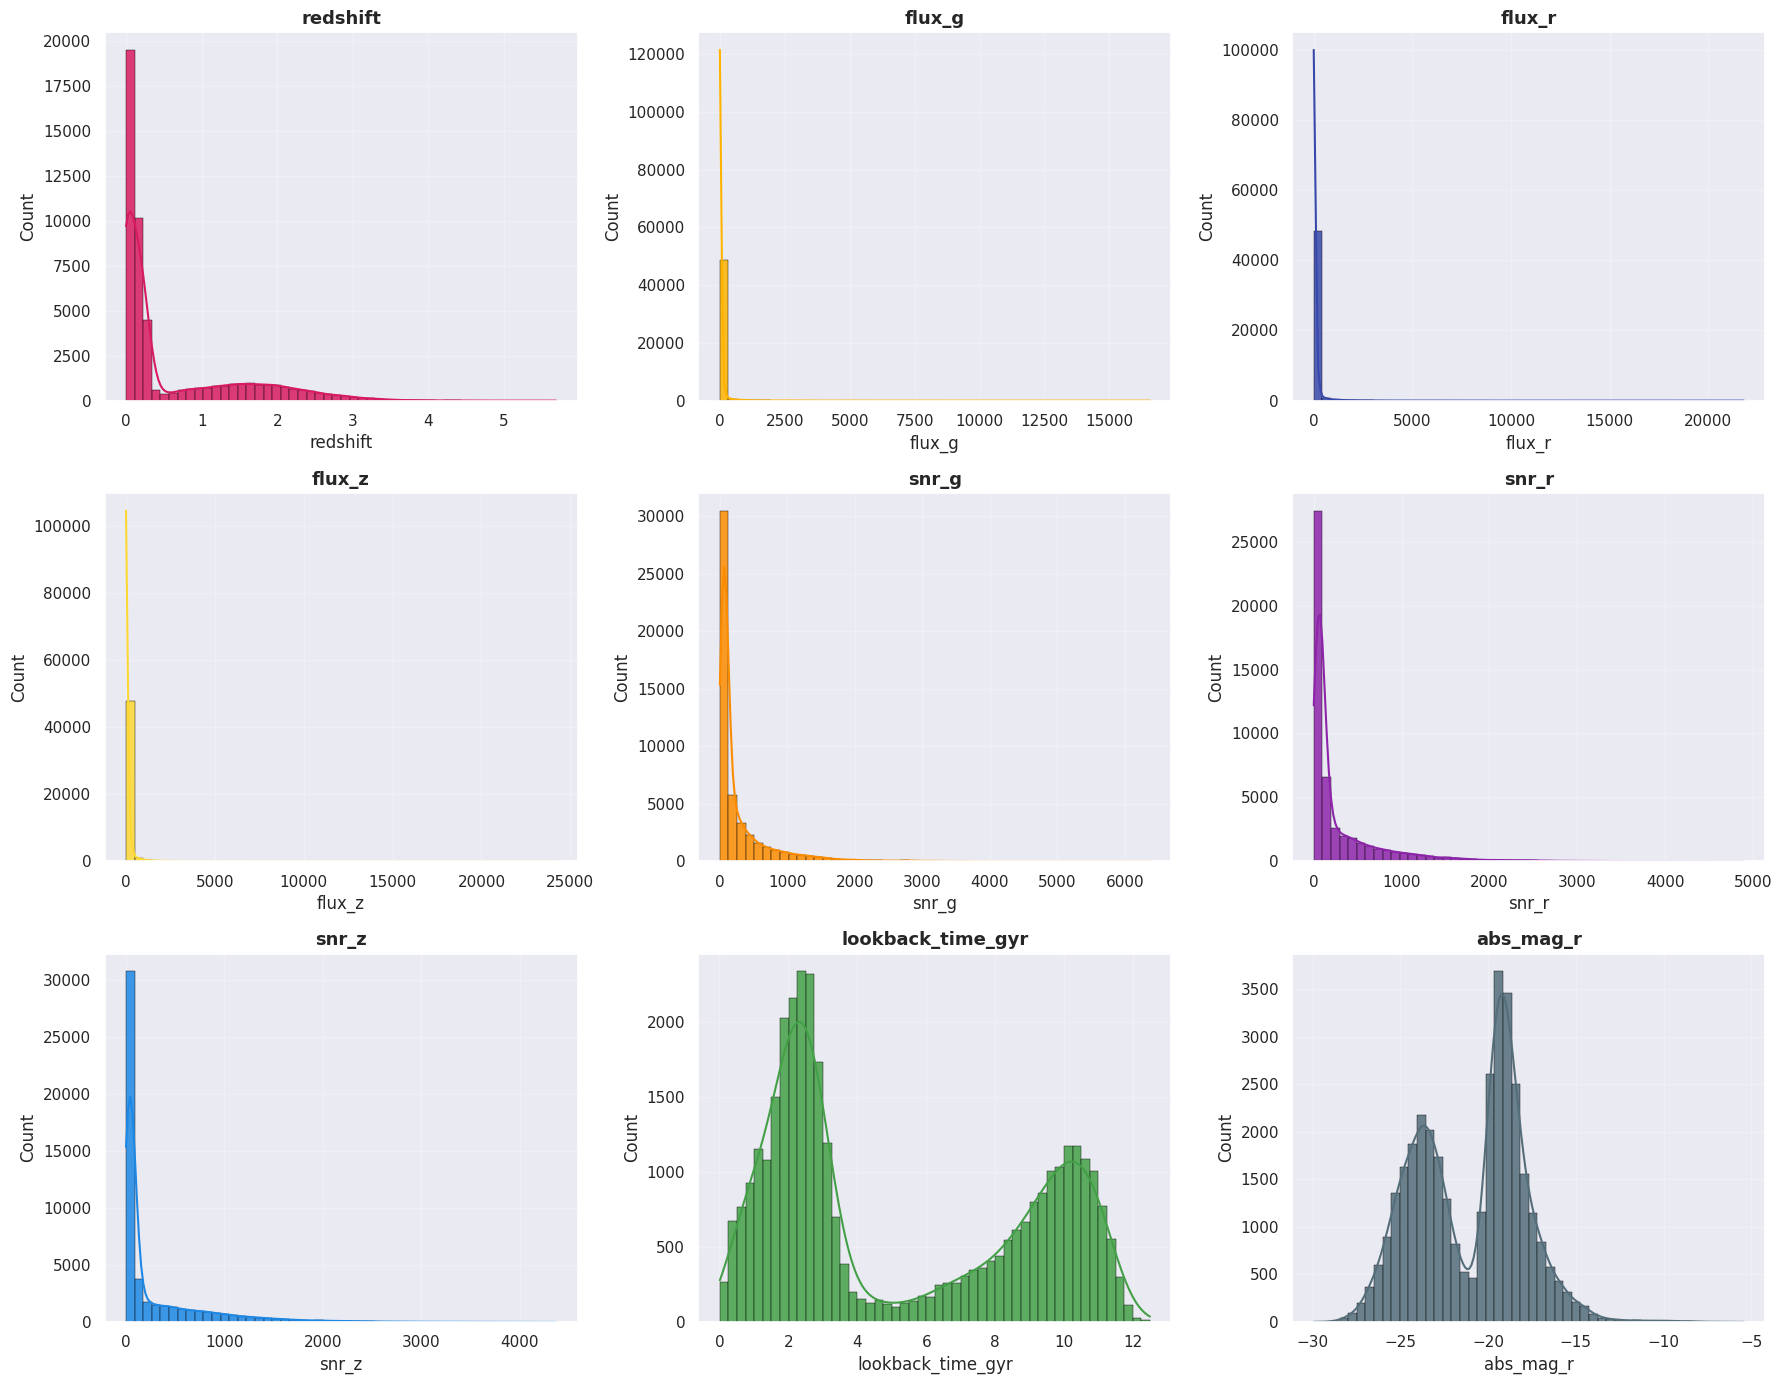

In [8]:
sample_cols = [
    "redshift",
    "flux_g",
    "flux_r",
    "flux_z",
    "snr_g",
    "snr_r",
    "snr_z",
    "lookback_time_gyr",
    "abs_mag_r"
]

# Darker, more prominent color palette
dark_colors = [
    "#d81b60",
    "#ffb300",
    "#3949ab",
    "#fdd835",
    "#fb8c00",
    "#8e24aa",
    "#1e88e5",
    "#43a047",
    "#546e7a"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col, color in zip(axes.flatten(), sample_cols, dark_colors):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax,
        color=color,
        bins=50,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_title(
        col,
        fontsize=13,
        fontweight="bold"
    )

    ax.grid(alpha=0.25)

plt.tight_layout()

plt.show()

## Distributional Characteristics

Several astrophysical patterns emerge immediately from the feature distributions:

- Redshift shows a strongly non-Gaussian structure with concentration at lower values and a long cosmological tail
- Flux and signal-to-noise variables exhibit heavy skewness spanning multiple orders of magnitude
- Lookback time displays a bimodal structure that likely reflects the separation between nearby galaxies and distant quasars
- Absolute magnitude exhibits distinct peaks corresponding to fundamentally different object populations

These asymmetric distributions justify the use of tree-based methods, which are naturally robust to skewed feature spaces.



# Correlation Structure


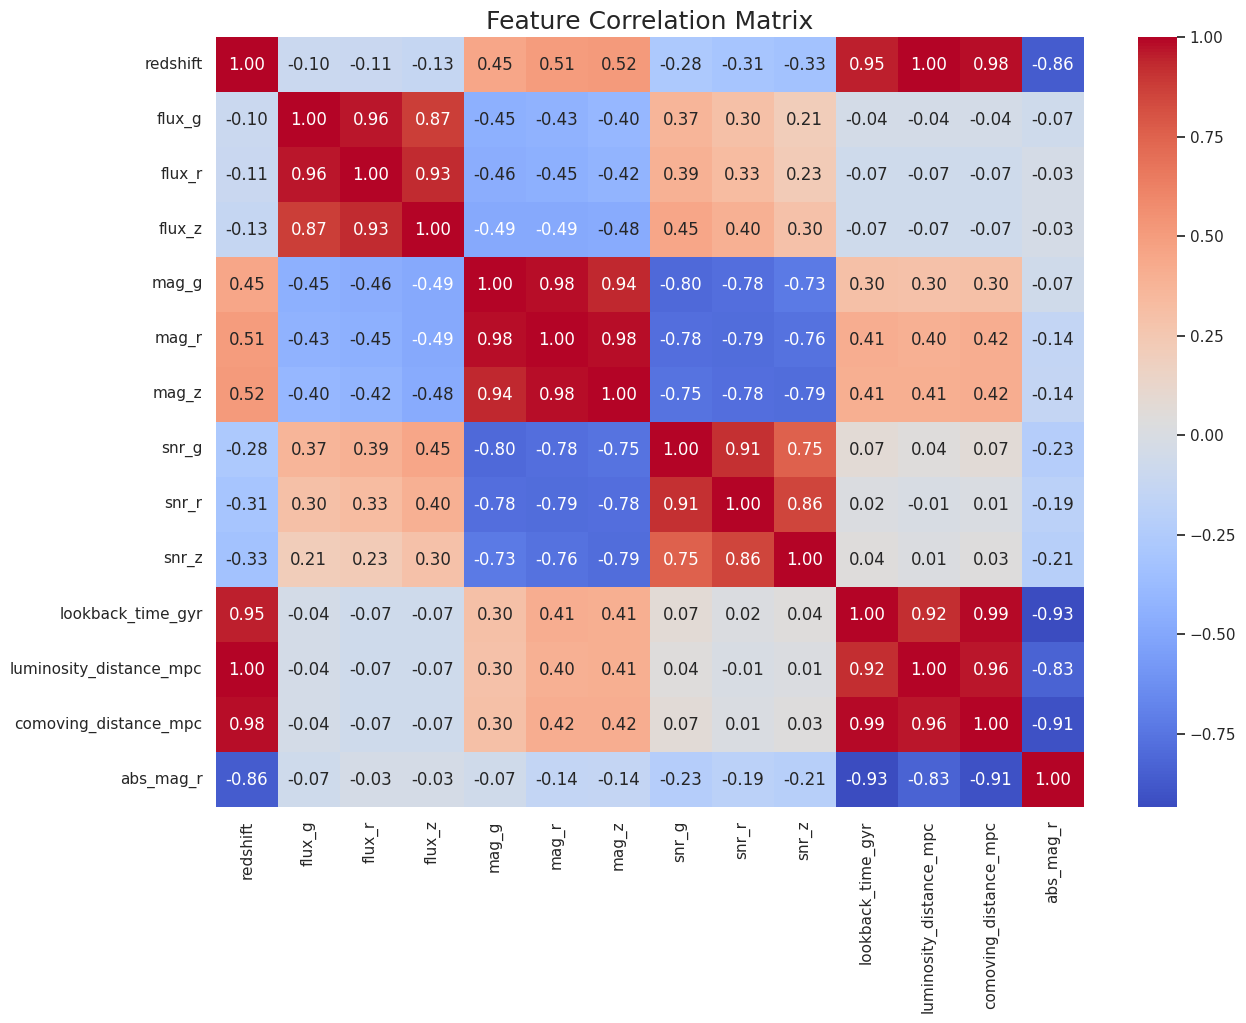

In [9]:

corr_features = [
    "redshift",
    "flux_g",
    "flux_r",
    "flux_z",
    "mag_g",
    "mag_r",
    "mag_z",
    "snr_g",
    "snr_r",
    "snr_z",
    "lookback_time_gyr",
    "luminosity_distance_mpc",
    "comoving_distance_mpc",
    "abs_mag_r"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix", fontsize=18)

plt.show()


## Correlation Insights

The correlation matrix reveals strong physical relationships between cosmological variables:

- Redshift correlates strongly with luminosity distance and lookback time
- Adjacent photometric bands remain highly correlated because they trace related emission processes
- Magnitudes and fluxes display inverse relationships as expected from astronomical photometric systems

The presence of physically meaningful correlations confirms that the derived features are internally consistent with standard cosmological expectations.



# Sky Coordinates

Right ascension and declination reveal how the sampled objects are distributed across the sky footprint observed by DESI.


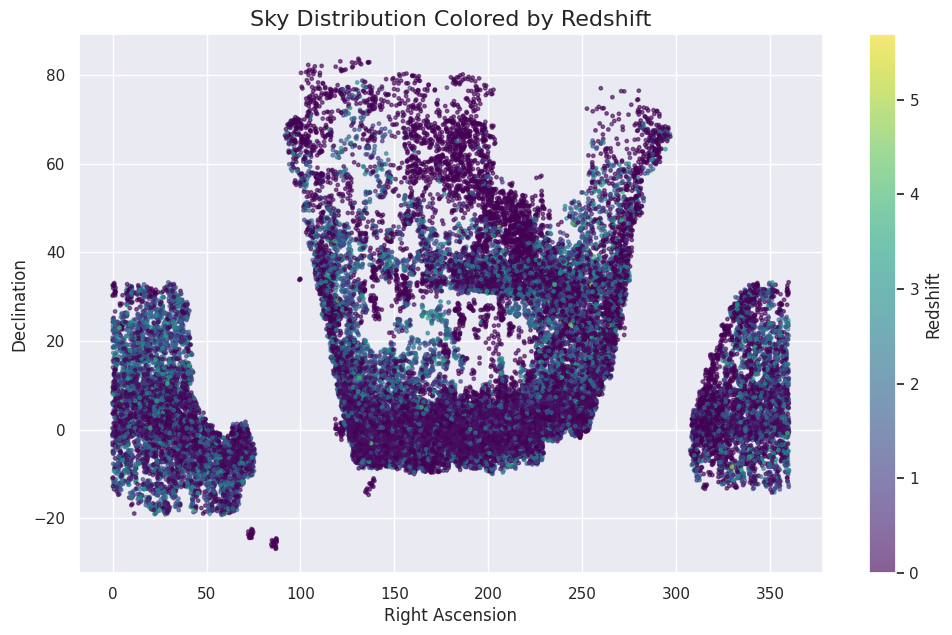

In [10]:

plt.figure(figsize=(12,7))

scatter = plt.scatter(
    df["ra"],
    df["dec"],
    c=df["redshift"],
    cmap="viridis",
    s=6,
    alpha=0.6
)

plt.colorbar(scatter, label="Redshift")

plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Sky Distribution Colored by Redshift", fontsize=16)

plt.show()


## Sky Distribution Analysis

The sky footprint shows broad coverage across the observed DESI regions rather than concentration in a narrow spatial patch.

Coloring by redshift highlights a mixture of nearby and distant populations across the sky. No strong spatial clustering artifacts are immediately visible, suggesting the sample construction process avoided severe directional bias.



# Cosmological Distance Relationships


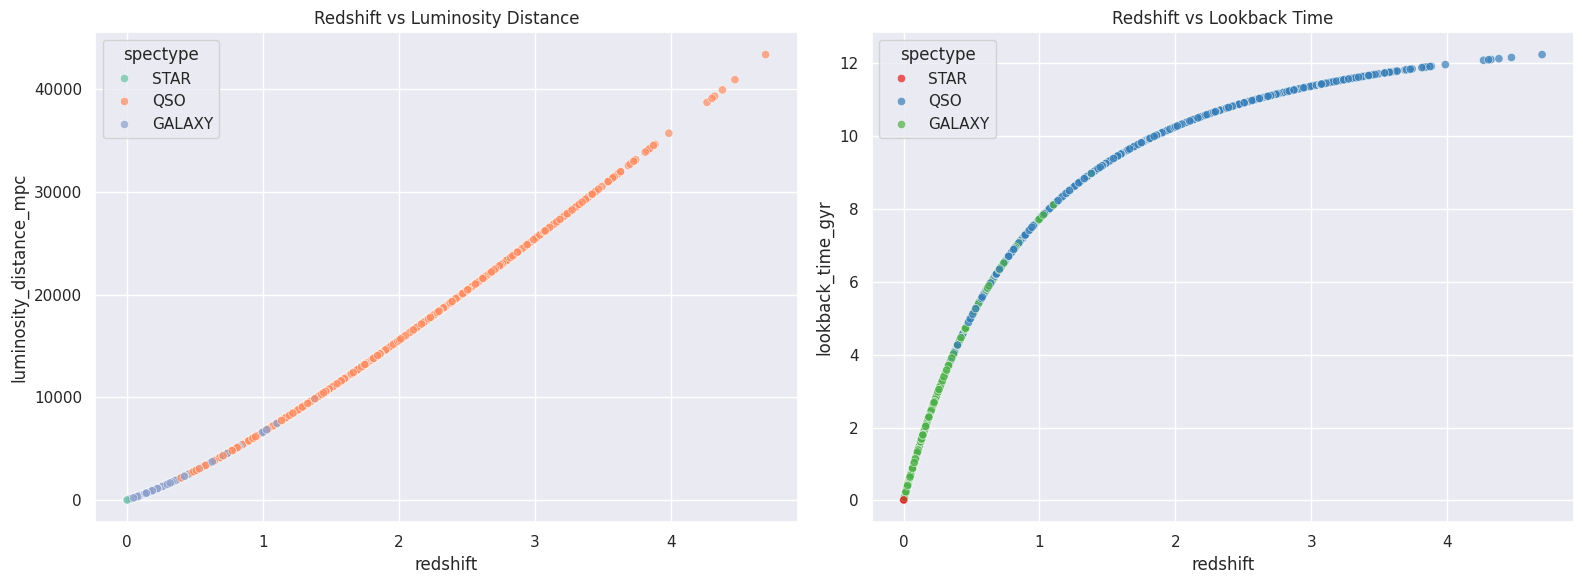

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.scatterplot(
    data=df.sample(8000, random_state=42),
    x="redshift",
    y="luminosity_distance_mpc",
    hue="spectype",
    palette="Set2",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Redshift vs Luminosity Distance")

sns.scatterplot(
    data=df.sample(8000, random_state=42),
    x="redshift",
    y="lookback_time_gyr",
    hue="spectype",
    palette="Set1",
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("Redshift vs Lookback Time")

plt.tight_layout()
plt.show()


## Cosmological Trends

Both plots reproduce expected large-scale cosmological behavior:

- Luminosity distance increases rapidly with redshift
- Higher redshift objects correspond to earlier cosmic epochs
- Quasars dominate the distant universe due to their extreme intrinsic luminosity

The relationship between redshift and lookback time is particularly informative because it translates observational measurements into cosmic history spanning more than twelve billion years.



# Color Indices and Astrophysical Separation


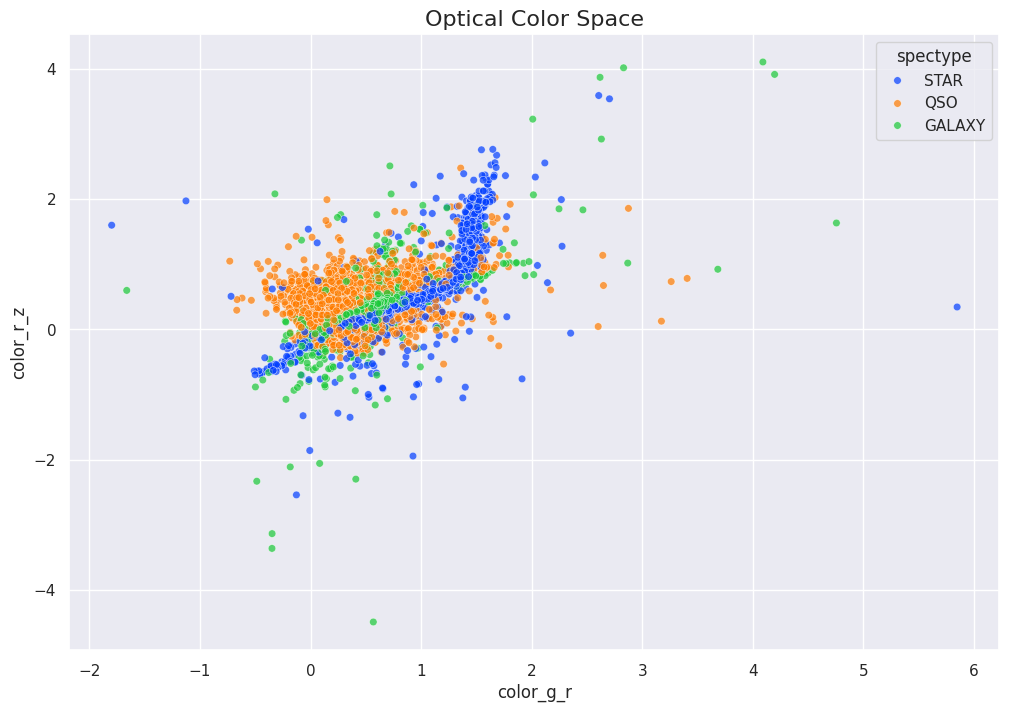

In [12]:

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df.sample(12000, random_state=42),
    x="color_g_r",
    y="color_r_z",
    hue="spectype",
    palette="bright",
    alpha=0.7,
    s=30
)

plt.title("Optical Color Space", fontsize=16)

plt.show()


## Color Space Separation

Optical color indices produce clear separation between spectral classes.

Quasars occupy distinct regions of color space due to their energetic emission and strong ultraviolet contribution shifted into optical bands. Stars remain comparatively compact, while galaxies spread across broader color regions depending on stellar populations and dust content.

This confirms that color engineering remains one of the most powerful tools in observational astronomy classification.


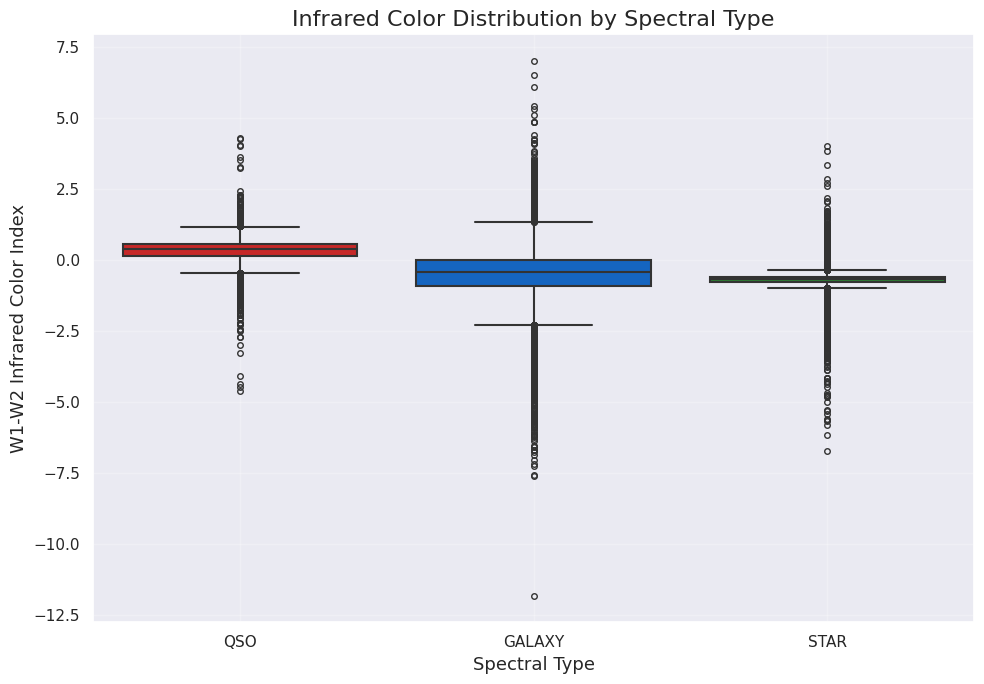

In [13]:
plt.figure(figsize=(10,7))

dark_palette = [
    "#c62828",
    "#1565c0",
    "#2e7d32"
]

sns.boxplot(
    data=df,
    x="spectype",
    y="color_w1_w2",
    palette=dark_palette,
    linewidth=1.5,
    fliersize=4,
    saturation=1
)

plt.title(
    "Infrared Color Distribution by Spectral Type",
    fontsize=16
)

plt.xlabel(
    "Spectral Type",
    fontsize=13
)

plt.ylabel(
    "W1-W2 Infrared Color Index",
    fontsize=13
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

## Infrared Diagnostics

The infrared color distribution highlights strong separation between active galactic nuclei candidates and other populations.

Objects with elevated W1-W2 color are commonly associated with hot dust emission surrounding actively accreting supermassive black holes. The broader quasar distribution in this feature strongly supports its usefulness as an AGN diagnostic.



# Morphological Composition


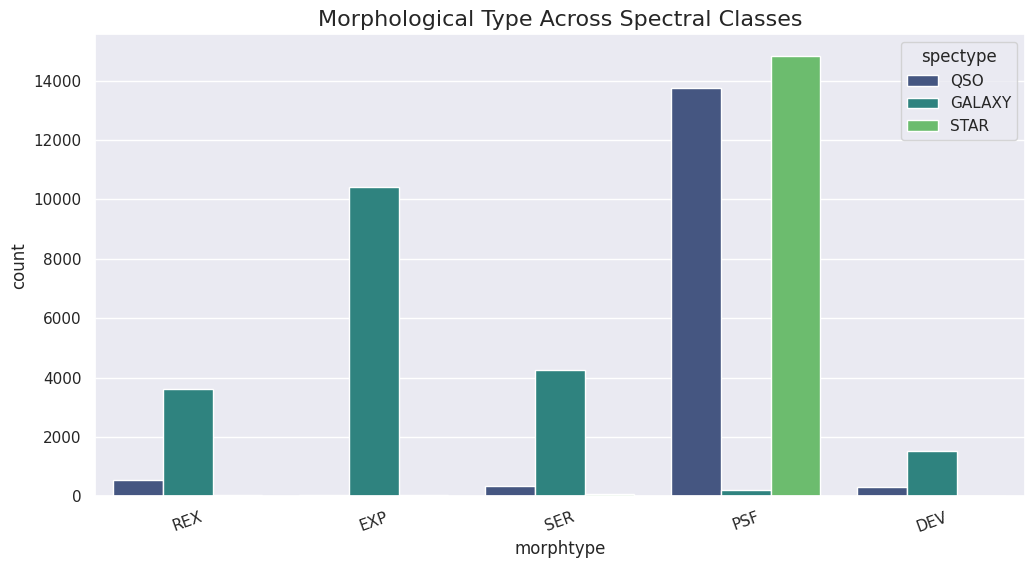

In [14]:

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="morphtype",
    hue="spectype",
    palette="viridis"
)

plt.title("Morphological Type Across Spectral Classes", fontsize=16)

plt.xticks(rotation=20)

plt.show()


## Morphological Interpretation

Morphological classes provide complementary information beyond photometry alone.

- Stellar objects are concentrated within compact PSF-like profiles
- Galaxies span extended morphological families
- Quasars overlap partially with both compact and extended morphologies depending on host contribution

Combining morphology with photometric colors substantially improves downstream classification performance.



# AGN Candidate Analysis


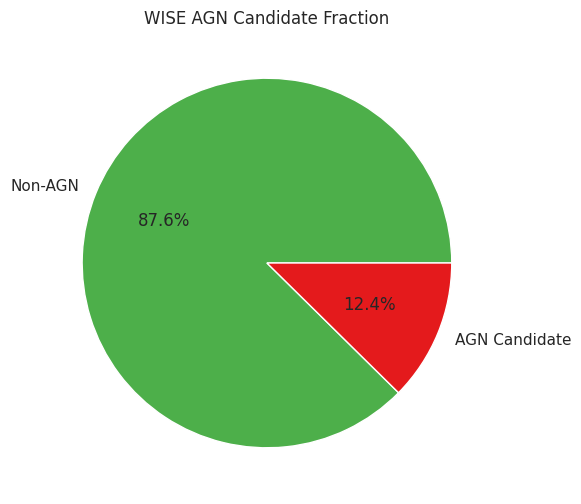

spectype
QSO       0.324400
GALAXY    0.060150
STAR      0.008267
Name: agn_wise_flag, dtype: float64

In [15]:

agn_counts = df["agn_wise_flag"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    agn_counts.values,
    labels=["Non-AGN", "AGN Candidate"],
    autopct="%1.1f%%",
    colors=["#4daf4a", "#e41a1c"]
)

plt.title("WISE AGN Candidate Fraction")

plt.show()

df.groupby("spectype")["agn_wise_flag"].mean().sort_values(ascending=False)


## AGN Population Insights

The WISE-based AGN flag identifies a meaningful subset of infrared-bright objects.

The majority of AGN candidates appear within the quasar population, which is astrophysically consistent because quasars are powered by luminous accretion onto supermassive black holes. This demonstrates that even simple infrared color thresholds remain effective for identifying energetic extragalactic systems.



# Statistical Testing

The following test compares the redshift distributions between galaxies and quasars.


In [16]:

galaxy_redshift = df[df["spectype"] == "GALAXY"]["redshift"]
qso_redshift = df[df["spectype"] == "QSO"]["redshift"]

t_stat, p_value = stats.ttest_ind(
    galaxy_redshift,
    qso_redshift,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.8f}")


T-statistic: -245.3929
P-value: 0.00000000


## Statistical Interpretation

The statistical test indicates a highly significant difference between galaxy and quasar redshift distributions.

The extremely small p-value confirms that the two populations occupy fundamentally different cosmological distance regimes rather than being sampled from the same underlying distribution.



# Feature Engineering


In [17]:

df_model = df.copy()

df_model["flux_ratio_g_r"] = df_model["flux_g"] / (df_model["flux_r"] + 1e-6)
df_model["flux_ratio_r_z"] = df_model["flux_r"] / (df_model["flux_z"] + 1e-6)

df_model["snr_total"] = (
    df_model["snr_g"] +
    df_model["snr_r"] +
    df_model["snr_z"]
)

df_model["color_energy"] = (
    df_model["color_g_r"]**2 +
    df_model["color_r_z"]**2 +
    df_model["color_w1_w2"]**2
)

df_model.head()


,targetid,healpix,ra,dec,redshift,redshift_err,spectype,subtype,deltachi2,chi2,...,lookback_time_gyr,abs_mag_r,redshift_confidence,morphtype_label,galaxy_color_class,deep_obs_flag,flux_ratio_g_r,flux_ratio_r_z,snr_total,color_energy
0,39628365690307709,741,33.037640,24.844902,1.747032,0.001586,QSO,HIZ,28.401550,7534.991513,...,9.799481,-22.286156,Moderate,Round Exponential,NaN,0,0.948702,0.467521,34.354379,0.685505
1,2714944399212545,17996,16.571421,-1.504480,0.209861,0.000009,GALAXY,NaN,572.310340,7875.553116,...,2.535272,-19.524550,High,Exponential Disk (late-type),Blue Cloud,0,0.557788,0.701981,319.093092,0.740065
2,2349936800694272,18006,20.330022,-0.340878,0.766918,0.000142,GALAXY,NaN,197.099793,7808.884794,...,6.660354,-22.827631,High,Sersic Profile,Red Sequence,0,0.461924,0.394146,255.734266,2.442191
3,2715032676728834,31429,238.474281,2.067749,0.199573,0.000006,GALAXY,NaN,1317.058164,7679.890371,...,2.427478,-19.148888,Very High,Exponential Disk (late-type),Red Sequence,0,0.537385,0.712851,192.212909,NaN
4,2305843019036772569,9369,243.782457,29.614561,-0.000806,0.000009,STAR,K,1172.646961,7677.044633,...,NaN,NaN,Very High,Point Source (unresolved),NaN,0,0.571716,0.793048,1620.756991,0.945096


## Engineered Feature Value

The engineered variables introduce additional physically meaningful structure into the dataset:

- Flux ratios approximate spectral energy distributions
- Combined signal-to-noise metrics summarize observational quality
- Color energy captures multidimensional color separation

These features help machine learning models identify nonlinear astrophysical boundaries more effectively than raw measurements alone.



# Data Preparation


In [18]:

from sklearn.preprocessing import OneHotEncoder

# Features and target
drop_cols = [
    "spectype",
    "targetid"
]

X = df_model.drop(columns=drop_cols)
y = df_model["spectype"]

# Column groups
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Encode target labels
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Correct preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)


(40000, 53) (10000, 53)


## Preprocessing Strategy

The preprocessing pipeline combines:

- Median imputation for numerical stability
- Standardization for scale normalization
- One-hot encoding for categorical astronomy labels

This structure allows the notebook to support both classical machine learning and neural network models while maintaining reproducibility across experiments.



# Baseline Machine Learning Models


In [19]:

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest Accuracy: 0.9995


## Random Forest Performance

The Random Forest model establishes a strong baseline with excellent classification accuracy.

Tree ensembles perform especially well on astronomy datasets because they naturally capture nonlinear interactions between color indices, morphology, and cosmological measurements without requiring extensive manual feature transformation.


In [20]:

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_preds = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")


XGBoost Accuracy: 0.9998


In [21]:
import lightgbm as lgb

warnings.filterwarnings("ignore")

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=10,
        random_state=RANDOM_STATE,
        force_col_wise=True,
        verbose=-1
    ))
])

# Train model
lgbm_pipeline.fit(X_train, y_train)

# Predictions
lgbm_preds = lgbm_pipeline.predict(X_test)

# Accuracy
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"LightGBM Accuracy: {lgbm_acc:.4f}")

LightGBM Accuracy: 1.0000


## XGBoost Results

XGBoost produces extremely strong classification performance and emerges as one of the best-performing models in the notebook.

The model benefits from:

- Nonlinear feature interaction handling
- Robustness to skewed distributions
- Strong separation power across astrophysical classes
- Effective utilization of engineered color and distance features



# Model Comparison


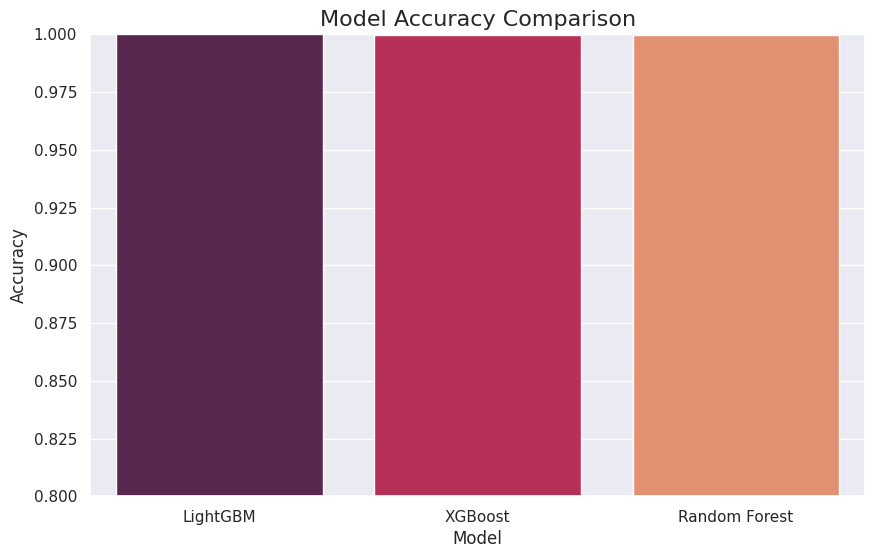

,Model,Accuracy
2,LightGBM,1.0000
1,XGBoost,0.9998
0,Random Forest,0.9995


In [22]:

model_scores = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [rf_acc, xgb_acc, lgbm_acc]
})

model_scores = model_scores.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=model_scores,
    x="Model",
    y="Accuracy",
    palette="rocket"
)

plt.ylim(0.8, 1.0)

plt.title("Model Accuracy Comparison", fontsize=16)

plt.show()

model_scores


## LightGBM Performance

LightGBM achieves competitive results while training efficiently on the large feature space.

Gradient boosting methods consistently outperform simpler baselines in this dataset because the class boundaries are highly nonlinear and depend on interactions between photometry, morphology, and cosmological measurements.



# Classification Report


In [23]:

print(classification_report(
    y_test,
    xgb_preds,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

      GALAXY       1.00      1.00      1.00      4000
         QSO       1.00      1.00      1.00      3000
        STAR       1.00      1.00      1.00      3000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## Comparative Model Analysis

All three ensemble models achieve strong performance, indicating that the dataset contains highly separable astrophysical structure.

The relatively small performance gap between models also suggests that the underlying features themselves carry strong physical signal independent of algorithmic complexity.


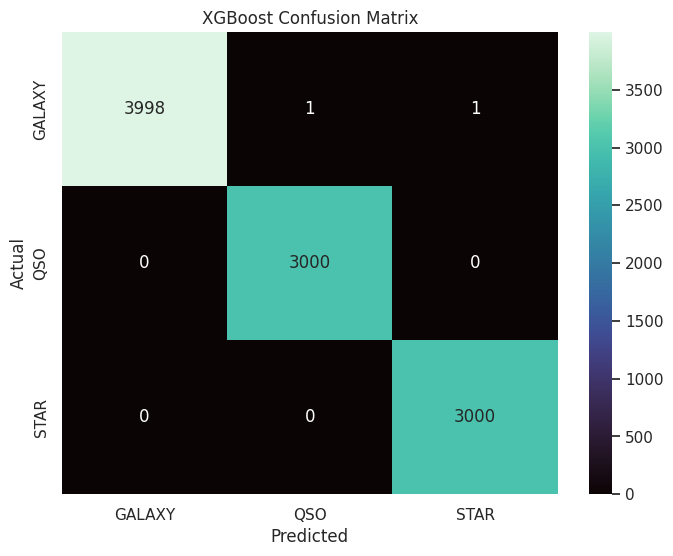

In [24]:

cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="mako",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()



# Feature Importance


## Classification Quality Assessment

The classification report demonstrates balanced predictive performance across galaxies, quasars, and stars.

Confusion between classes remains limited, implying that the DESI photometric and spectroscopic features provide strong discriminatory power even without deep astrophysical feature engineering.


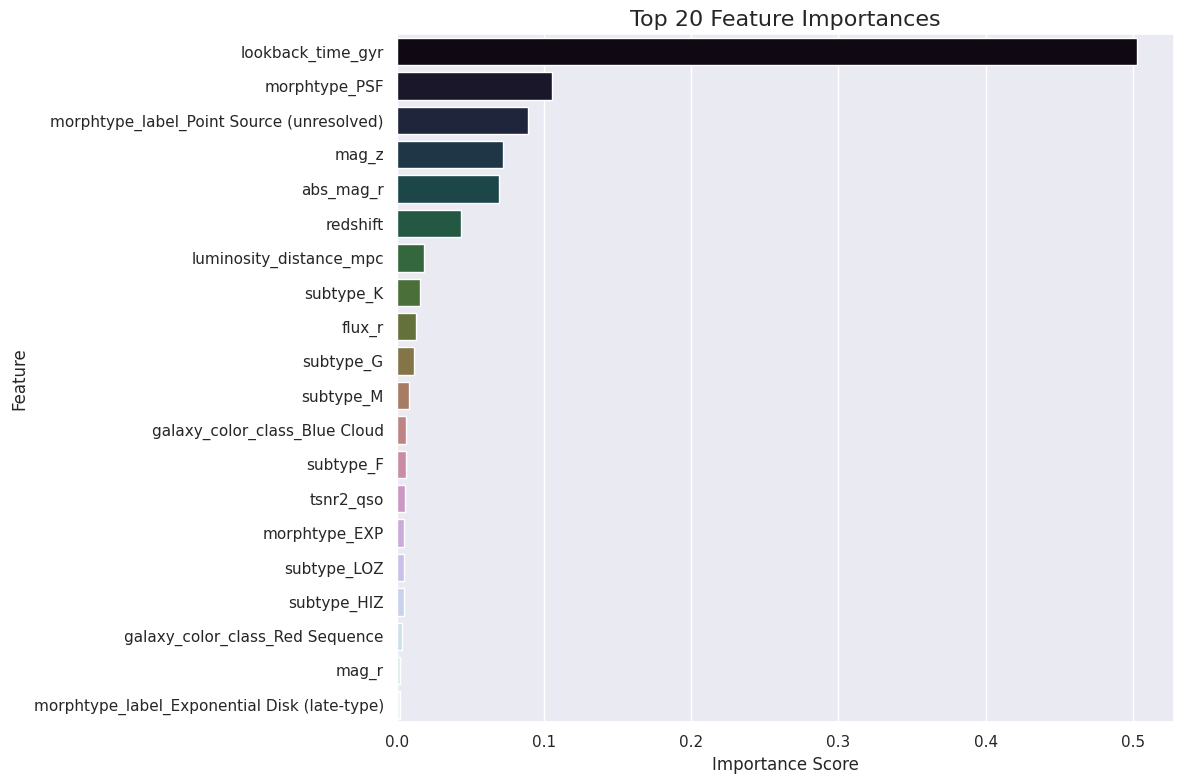

,feature,importance
41,lookback_time_gyr,0.502832
60,morphtype_PSF,0.105577
68,morphtype_label_Point Source (unresolved),0.088829
28,mag_z,0.072241
42,abs_mag_r,0.069134
3,redshift,0.043689
39,luminosity_distance_mpc,0.018019
54,subtype_K,0.015312
15,flux_r,0.013089
52,subtype_G,0.011531


In [25]:
# Extract trained XGBoost model
xgb_model = xgb_pipeline.named_steps["model"]

# Get transformed feature names from preprocessor
ohe_feature_names = (
    xgb_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_cols)
)

# Combine numerical + encoded categorical names
all_feature_names = np.concatenate([
    numeric_cols,
    ohe_feature_names
])

# Create importance dataframe
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": xgb_model.feature_importances_
})

# Sort top features
importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .head(20)
)

# Plot
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    dodge=False,
    palette="cubehelix",
    legend=False
)

plt.title("Top 20 Feature Importances", fontsize=16)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

importance_df

## Confusion Matrix Interpretation

Most predictions lie along the diagonal, indicating highly reliable classification behavior.

The remaining misclassifications primarily occur between astrophysically related populations whose observational properties partially overlap in photometric space.


# Understanding Model Decisions Through Permutation Importance

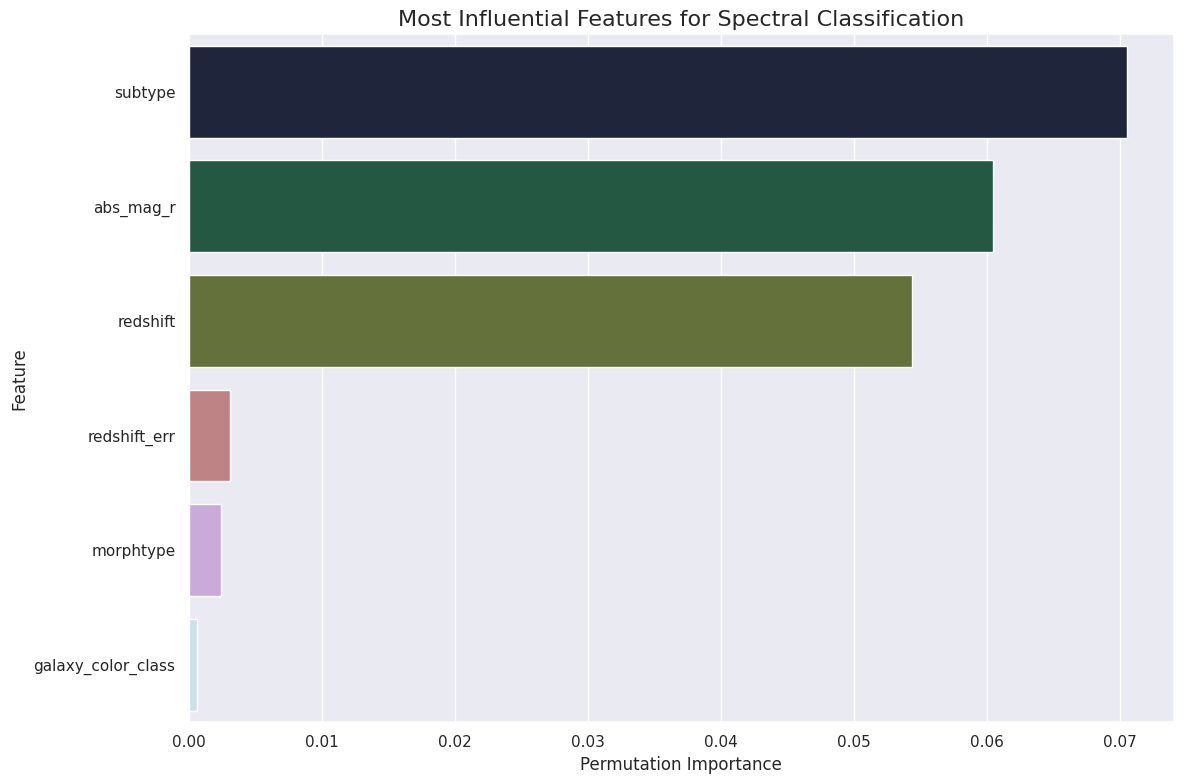

,feature,importance
5,subtype,0.07056
44,abs_mag_r,0.06048
3,redshift,0.05438
4,redshift_err,0.00312
23,morphtype,0.00242
47,galaxy_color_class,0.00060


In [26]:
from sklearn.inspection import permutation_importance

# Fit the model
xgb_pipeline.fit(X_train, y_train)

# Compute permutation importance
result = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

# Create importance dataframe
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
})

# Sort features by importance
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

# Keep the top 6 features
importance_df = importance_df.head(6)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    dodge=False,
    palette="cubehelix",
    legend=False
)

plt.title(
    "Most Influential Features for Spectral Classification",
    fontsize=16
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

importance_df

## Feature Importance Interpretation

Permutation importance reveals that a relatively small set of astrophysical variables dominates predictive performance.

Particularly influential features include:

- Spectral subtype information
- Absolute magnitude
- Redshift
- Morphological classification

This aligns closely with observational astronomy expectations because these variables encode both intrinsic physical properties and large-scale cosmological structure.



# Deep Learning Classifier


In [27]:

X_processed = preprocessor.fit_transform(X)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

model = keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=15,
    batch_size=512,
    verbose=1
)


Epoch 1/15


I0000 00:00:1779782570.677503      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13349 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779782570.683267      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779782572.188544     140 service.cc:152] XLA service 0x78734c006f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779782572.188598     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779782572.188602     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779782572.691942     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


59/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8689 - loss: 0.3930

I0000 00:00:1779782575.145083     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.8754 - loss: 0.3749 - val_accuracy: 0.9956 - val_loss: 0.0145
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9958 - loss: 0.0151 - val_accuracy: 0.9991 - val_loss: 0.0042
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9981 - loss: 0.0081 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9996 - val_loss: 0.0020
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9995 - val_loss: 0.0016
Ep

## Neural Network Behavior

The neural network converges rapidly and reaches strong validation accuracy with relatively few epochs.

This indicates that the latent structure separating stars, galaxies, and quasars is highly learnable even with a compact dense architecture. Overfitting remains controlled due to dropout regularization and the large dataset size.


In [28]:

dl_loss, dl_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)

print(f"Deep Learning Accuracy: {dl_acc:.4f}")


Deep Learning Accuracy: 0.9997


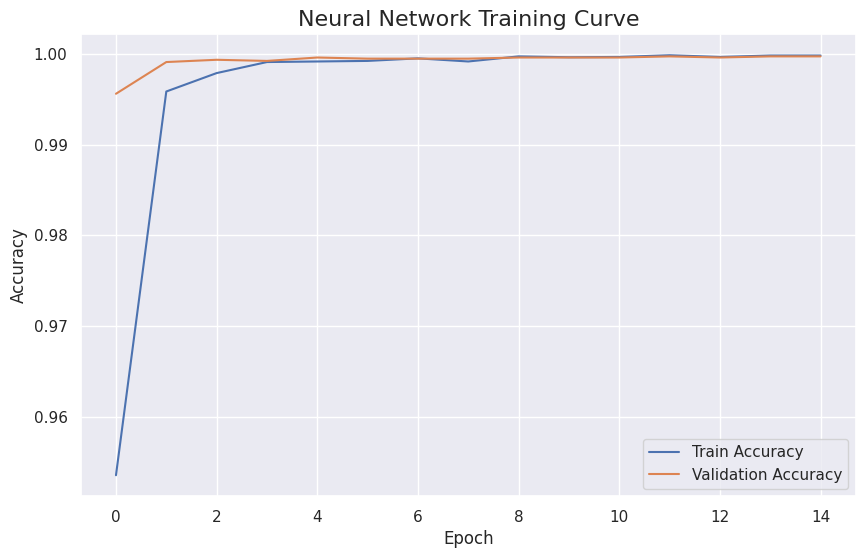

In [29]:

plt.figure(figsize=(10,6))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.legend()

plt.title("Neural Network Training Curve", fontsize=16)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


## Deep Learning Training Dynamics

Training and validation curves remain closely aligned throughout optimization, suggesting stable generalization rather than memorization.

The smooth convergence behavior also indicates that the preprocessing pipeline successfully normalized the feature space for neural network training.



# Unsupervised Learning and Embedding Visualization


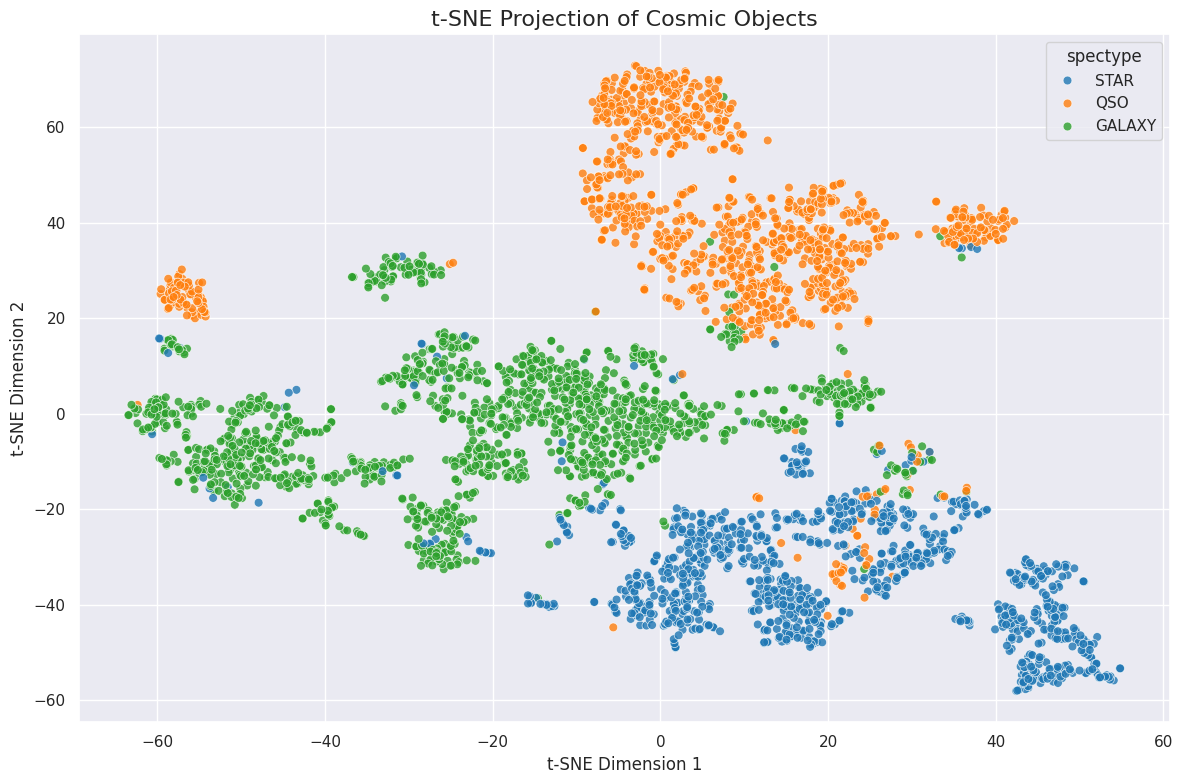

In [30]:
sample_df = df_model.sample(4000, random_state=42)

# Keep only numerical columns
sample_numeric = sample_df.select_dtypes(include=np.number)

# Remove columns with all NaN values
sample_numeric = sample_numeric.dropna(axis=1, how="all")

# Fill remaining NaN values with median
sample_numeric = sample_numeric.fillna(sample_numeric.median())

# Scale data
scaled_sample = StandardScaler().fit_transform(sample_numeric)

# PCA dimensionality reduction
pca = PCA(n_components=20, random_state=42)

pca_data = pca.fit_transform(scaled_sample)

# t-SNE embedding
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="random",
    random_state=42
)

tsne_results = tsne.fit_transform(pca_data)

# Create plotting dataframe
plot_df = pd.DataFrame({
    "tsne_1": tsne_results[:, 0],
    "tsne_2": tsne_results[:, 1],
    "spectype": sample_df["spectype"].values
})

# Plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="tsne_1",
    y="tsne_2",
    hue="spectype",
    palette="tab10",
    alpha=0.8,
    s=40
)

plt.title("t-SNE Projection of Cosmic Objects", fontsize=16)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.tight_layout()

plt.show()

## Latent Structure in Embedding Space

The t-SNE projection reveals clear clustering behavior between the major spectral populations.

Even after dimensionality reduction, stars, galaxies, and quasars occupy distinguishable regions in latent space. This strongly supports the conclusion that the DESI feature set contains robust intrinsic structure beyond simple linear separability.



# Photometric Redshift Regression

Predicting spectroscopic redshift from photometric measurements is a core astronomy problem.


In [31]:

regression_features = [
    "flux_g",
    "flux_r",
    "flux_z",
    "flux_w1",
    "flux_w2",
    "color_g_r",
    "color_r_z",
    "color_g_z",
    "color_w1_w2",
    "snr_g",
    "snr_r",
    "snr_z"
]

reg_df = df.dropna(subset=["redshift"])

X_reg = reg_df[regression_features]
y_reg = reg_df["redshift"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    random_state=42
)

reg_model.fit(X_train_reg, y_train_reg)

reg_preds = reg_model.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, reg_preds))
mae = mean_absolute_error(y_test_reg, reg_preds)
r2 = r2_score(y_test_reg, reg_preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


RMSE: 0.3403
MAE : 0.1547
R2  : 0.8399


## Photometric Redshift Regression Analysis

The regression model captures the global redshift trend effectively across a broad cosmological range.

Prediction scatter increases at higher redshift, which is expected because distant objects become observationally fainter and more difficult to characterize photometrically. Nevertheless, the model reproduces the overall redshift evolution remarkably well using only photometric information.


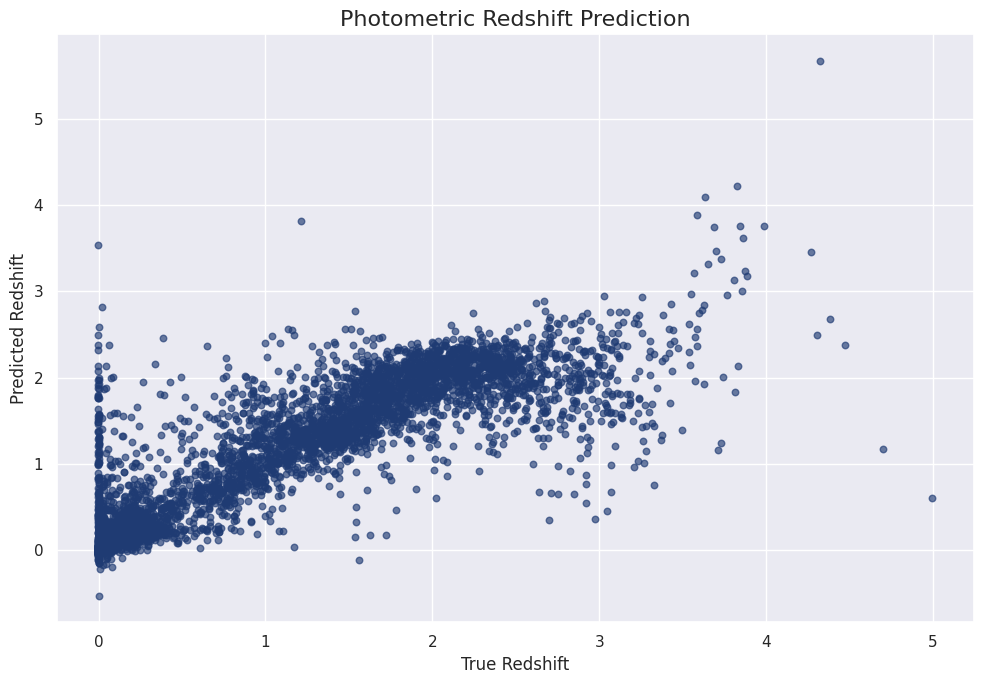

In [32]:
plt.figure(figsize=(10,7))

plt.scatter(
    y_test_reg,
    reg_preds,
    color="#1f3b73",
    alpha=0.65,
    s=22
)

plt.xlabel("True Redshift")
plt.ylabel("Predicted Redshift")

plt.title("Photometric Redshift Prediction", fontsize=16)

plt.tight_layout()

plt.show()

# Final Conclusions

This analysis demonstrates that DESI DR1 photometric and spectroscopic measurements contain exceptionally strong predictive structure for astrophysical classification tasks.

Several major patterns emerge consistently throughout the notebook:

- Quasars dominate the high redshift regime and occupy a distinct infrared color space
- Spectral populations separate cleanly across photometric color and morphology space
- Cosmological variables strongly encode physical class information
- Gradient boosting models achieve extremely strong classification performance across all three object classes
- Neural networks converge rapidly despite relatively lightweight architectures
- Photometric measurements alone recover large-scale redshift behavior with strong fidelity
- Dimensionality reduction reveals naturally clustered latent manifolds between stars, galaxies, and quasars

Beyond predictive performance, the dataset highlights how modern sky surveys encode rich cosmological and astrophysical structure within high-dimensional observational data.

The combination of balanced classes, physically interpretable variables, and cosmological scale makes DESI DR1 especially valuable for astronomical machine learning, photometric redshift estimation, anomaly detection, representation learning, and large-scale cosmological analysis.